# CSCA-5642. Final project

# Untilizing cGAN approach to colorize grayscale images

# Dataset

In [ ]:
DATASET_DIR = '/kaggle/input/places365'
WORKING_DIR = '/kaggle/working'

In [ ]:
!du -sh /kaggle/working/train
!du -sh /kaggle/working/val

In [76]:
import io
import os
import subprocess
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import tensorflow as tf
import numpy as np

In [77]:
import os
import subprocess

SELECTED_CATEGORIES = [
    'badlands', 'bamboo_forest', 'butte', 'canyon', 'cliff', 'coast', 'corn_field', 'creek', 'crevasse',
    'desert-sand', 'field-cultivated', 'field-wild', 'field_road', 'forest-broadleaf', 'forest_path',
    'forest_road', 'glacier', 'hayfield', 'hot_spring', 'ice_floe', 'ice_shelf', 'iceberg', 'islet', 'lagoon',
    'lake-natural', 'marsh', 'mountain', 'mountain_path', 'mountain_snowy', 'ocean', 'pasture', 'pond',
    'rainforest', 'river', 'snowfield', 'swamp', 'tundra', 'volcano', 'waterfall']


for subset in ['train', 'val']:
    for cat in SELECTED_CATEGORIES:
        if os.path.exists(os.path.join(WORKING_DIR, subset, cat)):
            continue
        
        dataset_subset_cat = os.path.join(DATASET_DIR, subset, cat)
        working_subset = os.path.join(WORKING_DIR, subset)
        os.makedirs(working_subset, exist_ok=True)   
        subprocess.call(['rsync', '-a', dataset_subset_cat, working_subset])

In [20]:
# The batch size of 1 produced better results for the U-Net in the original pix2pix experiment
BATCH_SIZE = 1
# Each image is 256x256 in size
IMG_WIDTH = 256
IMG_HEIGHT = 256

In [ ]:
def to_m11(image):  # from [0.0, 1.0] to [-1.0, 1.0]
    return image * 2.0 - 1.0

def to_01(image):  # from [-1.0, 1.0] to [0.0, 1.0]
    return image * 0.5 + 0.5

def to_unit8(image):  # from [0.0, 1.0] to [0, 255]
    image = np.array(image) * 255.0
    return image.astype(np.uint8)

def to_gray_and_rgb(rgb_batch):
    rgb_batch = tf.cast(rgb_batch, tf.float32) / 255.0
    gray_batch = tf.image.rgb_to_grayscale(rgb_batch)
    return to_m11(gray_batch), to_m11(rgb_batch)

def get_dataset(directory):
    rgb_dataset = tf.keras.utils.image_dataset_from_directory(
        directory,
        labels=None,
        batch_size=BATCH_SIZE,
        image_size=(IMG_WIDTH, IMG_HEIGHT),
        seed=5642
    )
    return rgb_dataset.map(to_gray_and_rgb)

In [22]:
train_dataset = get_dataset(os.path.join(WORKING_DIR, 'train'))
val_dataset = get_dataset(os.path.join(WORKING_DIR, 'val'))

Found 194457 files.
Found 3900 files.


# Exploratory Data Analysis (EDA)

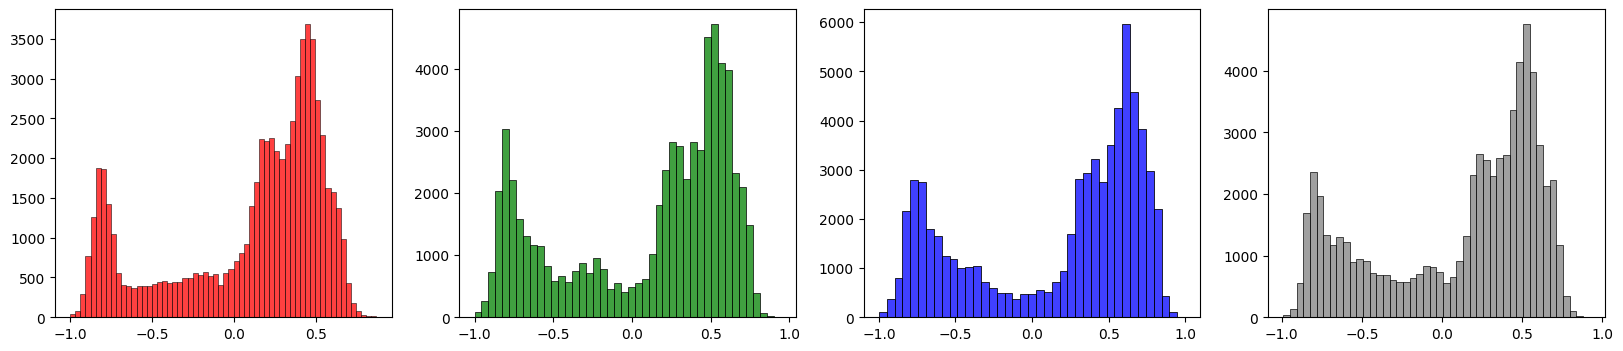

In [ ]:
gray_image_batch, rgb_image_batch = next(iter(val_dataset))

#import warnings
#warnings.filterwarnings("ignore", category=FutureWarning, message=".*use_inf_as_na.*")

fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(20, 4))
sns.histplot(tf.reshape(rgb_image_batch[:, :, :, 0], [-1]), ax=ax[0], color='red')
sns.histplot(tf.reshape(rgb_image_batch[:, :, :, 1], [-1]), ax=ax[1], color='green')
sns.histplot(tf.reshape(rgb_image_batch[:, :, :, 2], [-1]), ax=ax[2], color='blue')
sns.histplot(tf.reshape(gray_image_batch[:, :, :], [-1]), ax=ax[3], color='gray')

for ax_i in ax:
    ax_i.set_ylabel('')
    
plt.show()

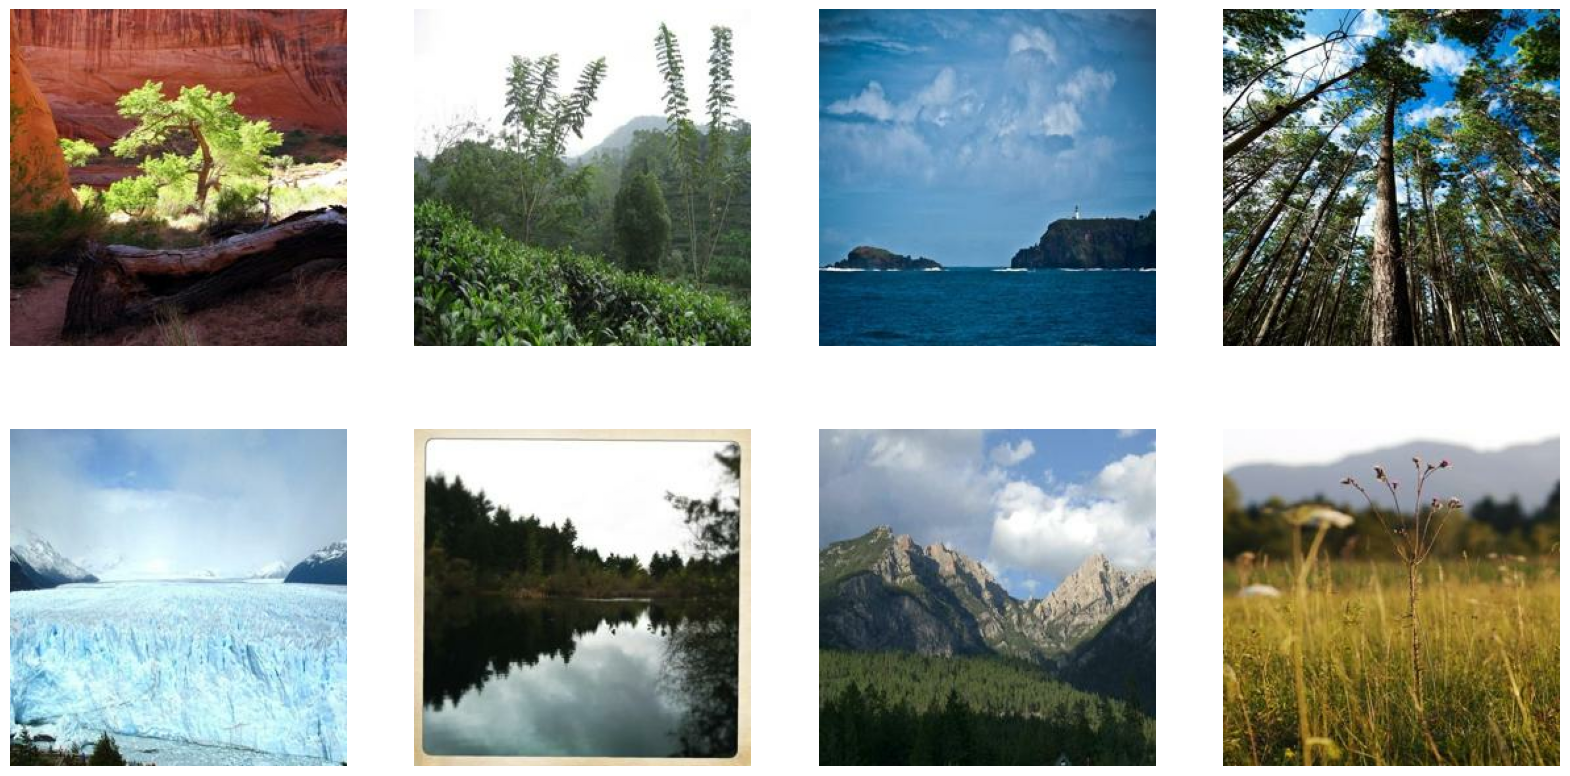

In [ ]:
n, m = 2, 4
fig, ax = plt.subplots(nrows=n, ncols=m, figsize=(m*5, n*5))
it = iter(val_dataset)
for i in range(n):
    for j in range (m):
        batch = next(it)
        ax[i, j].imshow(to_01(batch[1][0]))
        ax[i, j].axis('off')
plt.show()

# Model Architecture

## Generator

In [2]:
OUTPUT_CHANNELS = 3

In [3]:
def downsample(filters, size, apply_batchnorm=True):
    initializer = tf.random_normal_initializer(0., 0.02)

    result = tf.keras.Sequential()
    result.add(
        tf.keras.layers.Conv2D(filters, size, strides=2, padding='same',
                             kernel_initializer=initializer, use_bias=False))

    if apply_batchnorm:
        result.add(tf.keras.layers.BatchNormalization())

    result.add(tf.keras.layers.LeakyReLU())

    return result

In [4]:
def upsample(filters, size, apply_dropout=False):
    initializer = tf.random_normal_initializer(0., 0.02)

    result = tf.keras.Sequential()
    result.add(
        tf.keras.layers.Conv2DTranspose(filters, size, strides=2,
                                        padding='same',
                                        kernel_initializer=initializer,
                                        use_bias=False))

    result.add(tf.keras.layers.BatchNormalization())

    if apply_dropout:
        result.add(tf.keras.layers.Dropout(0.5))

    result.add(tf.keras.layers.ReLU())

    return result

In [5]:
def Generator():
    inputs = tf.keras.layers.Input(shape=[256, 256, 1])  # 1 - means grayscale

    down_stack = [
        downsample(64, 4, apply_batchnorm=False),  # (batch_size, 128, 128, 64)
        downsample(128, 4),  # (batch_size, 64, 64, 128)
        downsample(256, 4),  # (batch_size, 32, 32, 256)
        downsample(512, 4),  # (batch_size, 16, 16, 512)
        downsample(512, 4),  # (batch_size, 8, 8, 512)
        downsample(512, 4),  # (batch_size, 4, 4, 512)
        downsample(512, 4),  # (batch_size, 2, 2, 512)
        downsample(512, 4),  # (batch_size, 1, 1, 512)
    ]

    up_stack = [
        upsample(512, 4, apply_dropout=True),  # (batch_size, 2, 2, 1024)
        upsample(512, 4, apply_dropout=True),  # (batch_size, 4, 4, 1024)
        upsample(512, 4, apply_dropout=True),  # (batch_size, 8, 8, 1024)
        upsample(512, 4),  # (batch_size, 16, 16, 1024)
        upsample(256, 4),  # (batch_size, 32, 32, 512)
        upsample(128, 4),  # (batch_size, 64, 64, 256)
        upsample(64, 4),  # (batch_size, 128, 128, 128)
    ]

    initializer = tf.random_normal_initializer(0., 0.02)
    last = tf.keras.layers.Conv2DTranspose(OUTPUT_CHANNELS, 4,
                                           strides=2,
                                           padding='same',
                                           kernel_initializer=initializer,
                                           activation='tanh')  # (batch_size, 256, 256, 3)

    x = inputs

    # Downsampling through the model
    skips = []
    for down in down_stack:
        x = down(x)
        skips.append(x)

    skips = reversed(skips[:-1])

    # Upsampling and establishing the skip connections
    for up, skip in zip(up_stack, skips):
        x = up(x)
        x = tf.keras.layers.Concatenate()([x, skip])

    x = last(x)

    return tf.keras.Model(inputs=inputs, outputs=x)

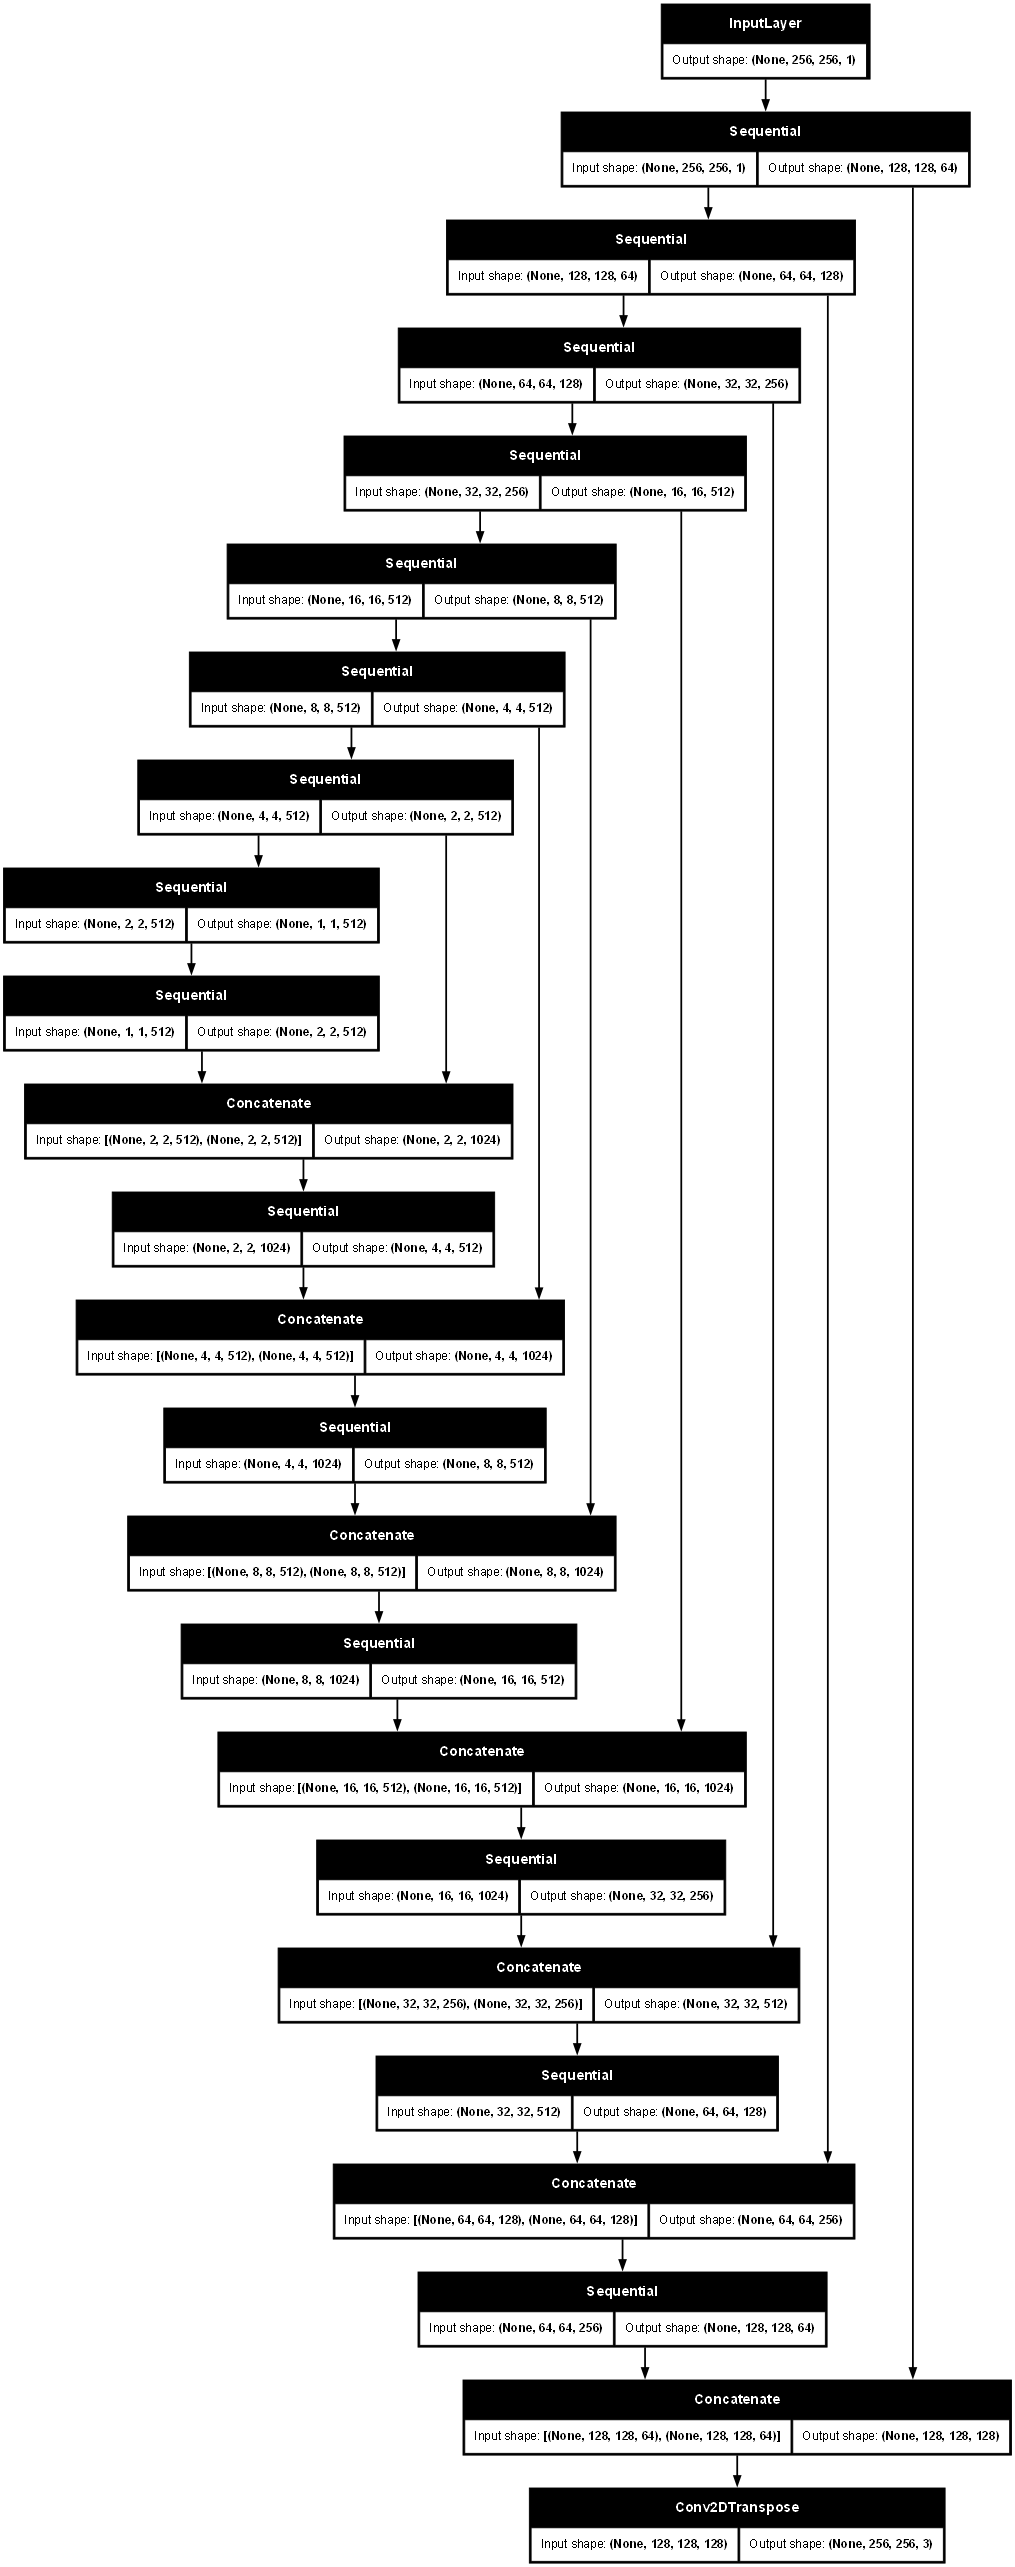

In [6]:
generator = Generator()
tf.keras.utils.plot_model(generator, show_shapes=True, dpi=64)

## Generator loss

In [7]:
LAMBDA = 100

In [8]:
loss_object = tf.keras.losses.BinaryCrossentropy(from_logits=True)

In [9]:
def generator_loss(disc_generated_output, gen_output, target, l1_loss_amplifier):
    gan_loss = loss_object(tf.ones_like(disc_generated_output), disc_generated_output)

    # Mean absolute error
    l1_loss = tf.reduce_mean(tf.abs(target - gen_output))

    total_gen_loss = gan_loss + (l1_loss_amplifier * l1_loss)

    return total_gen_loss, gan_loss, l1_loss

## Discriminator

In [10]:
def Discriminator():
    initializer = tf.random_normal_initializer(0., 0.02)

    inp = tf.keras.layers.Input(shape=[256, 256, 1], name='input_image')  # 1 - means grayscale
    tar = tf.keras.layers.Input(shape=[256, 256, 3], name='target_image')

    x = tf.keras.layers.concatenate([inp, tar])  # (batch_size, 256, 256, channels*2)

    down1 = downsample(64, 4, False)(x)  # (batch_size, 128, 128, 64)
    down2 = downsample(128, 4)(down1)  # (batch_size, 64, 64, 128)
    down3 = downsample(256, 4)(down2)  # (batch_size, 32, 32, 256)

    zero_pad1 = tf.keras.layers.ZeroPadding2D()(down3)  # (batch_size, 34, 34, 256)
    conv = tf.keras.layers.Conv2D(512, 4, strides=1,
                                  kernel_initializer=initializer,
                                  use_bias=False)(zero_pad1)  # (batch_size, 31, 31, 512)

    batchnorm1 = tf.keras.layers.BatchNormalization()(conv)

    leaky_relu = tf.keras.layers.LeakyReLU()(batchnorm1)

    zero_pad2 = tf.keras.layers.ZeroPadding2D()(leaky_relu)  # (batch_size, 33, 33, 512)

    last = tf.keras.layers.Conv2D(1, 4, strides=1,
                                  kernel_initializer=initializer)(zero_pad2)  # (batch_size, 30, 30, 1)

    return tf.keras.Model(inputs=[inp, tar], outputs=last)

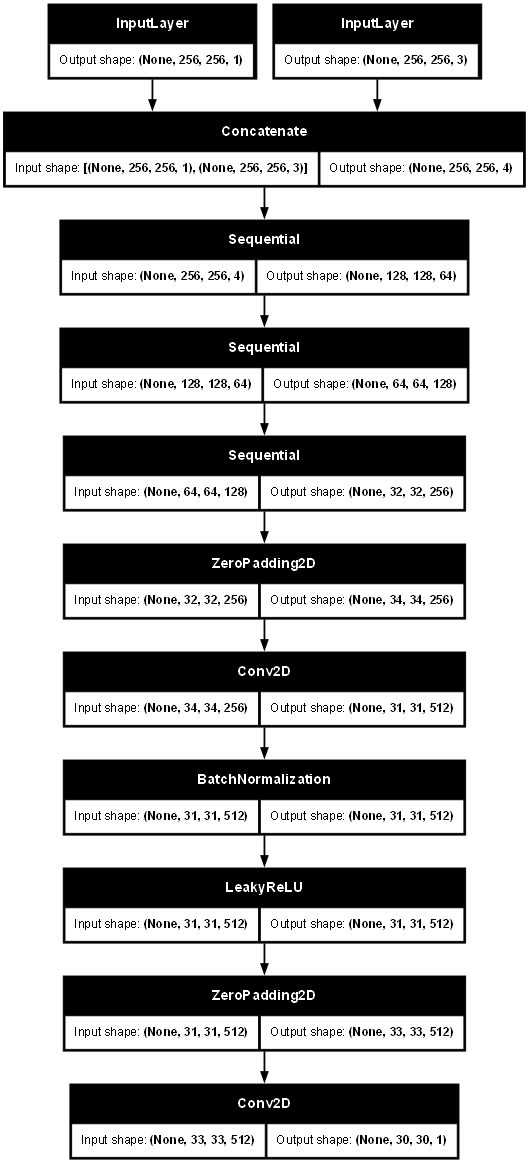

In [11]:
discriminator = Discriminator()
tf.keras.utils.plot_model(discriminator, show_shapes=True, dpi=64)

## Discriminator loss

In [12]:
def discriminator_loss(disc_real_output, disc_generated_output):
    real_loss = loss_object(tf.ones_like(disc_real_output), disc_real_output)

    generated_loss = loss_object(tf.zeros_like(disc_generated_output), disc_generated_output)

    total_disc_loss = real_loss + generated_loss

    return total_disc_loss

## Optimizers

In [13]:
generator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

## Model class

In [ ]:
class ConditionalGan(tf.keras.Model):
    def __init__(self, generator, discriminator):
        super().__init__()
        self.generator = generator
        self.discriminator = discriminator

        self.gen_total_loss_tracker = tf.keras.metrics.Mean(name="gen_total_loss")
        self.gen_gan_loss_tracker = tf.keras.metrics.Mean(name="gen_gan_loss")
        self.gen_l1_loss_tracker = tf.keras.metrics.Mean(name="gen_l1_loss")
        self.disc_loss_tracker = tf.keras.metrics.Mean(name="disc_loss")

    def compile(self, generator_optimizer, discriminator_optimizer):
        super(ConditionalGan, self).compile()
        self.generator_optimizer = generator_optimizer
        self.discriminator_optimizer = discriminator_optimizer

    @property
    def metrics(self):        
        return [
            self.gen_total_loss_tracker,
            self.gen_gan_loss_tracker,
            self.gen_l1_loss_tracker,
            self.disc_loss_tracker
        ]
    
    @tf.function
    def train_step(self, data):
        input_image, target_image = data

        with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
            gen_output = self.generator(input_image, training=True)
            disc_real_output = self.discriminator([input_image, target_image], training=True)
            disc_generated_output = self.discriminator([input_image, gen_output], training=True)
            gen_total_loss, gen_gan_loss, gen_l1_loss = generator_loss(disc_generated_output, gen_output, target_image)
            disc_loss = discriminator_loss(disc_real_output, disc_generated_output)

        self.gen_total_loss_tracker.update_state(gen_total_loss)
        self.gen_gan_loss_tracker.update_state(gen_gan_loss)
        self.gen_l1_loss_tracker.update_state(gen_l1_loss)
        self.disc_loss_tracker.update_state(disc_loss)

        generator_gradients = gen_tape.gradient(gen_total_loss, self.generator.trainable_variables)
        discriminator_gradients = disc_tape.gradient(disc_loss, self.discriminator.trainable_variables)

        self.generator_optimizer.apply_gradients(zip(generator_gradients, self.generator.trainable_variables))
        self.discriminator_optimizer.apply_gradients(zip(discriminator_gradients,self.discriminator.trainable_variables))

        return {m.name: m.result() for m in self.metrics}
    
    @tf.function
    def test_step(self, data):
        input_image, target_image = data

        gen_output = self.generator(input_image, training=False)
        disc_real_output = self.discriminator([input_image, target_image], training=False)
        disc_generated_output = self.discriminator([input_image, gen_output], training=False)
        gen_total_loss, gen_gan_loss, gen_l1_loss = generator_loss(disc_generated_output, gen_output, target_image)
        disc_loss = discriminator_loss(disc_real_output, disc_generated_output)

        self.gen_total_loss_tracker.update_state(gen_total_loss)
        self.gen_gan_loss_tracker.update_state(gen_gan_loss)
        self.gen_l1_loss_tracker.update_state(gen_l1_loss)
        self.disc_loss_tracker.update_state(disc_loss)

        return {m.name: m.result() for m in self.metrics}

# Training

In [ ]:
import json

def save_metrics(data, file_path):
    with open(file_path, 'w') as f:
        json.dump(data, f, indent=4)

def load_metrics(file_path):
    with open(file_path) as f:
        return json.load(f)


class ModelEpochEndCheckpoint(tf.keras.callbacks.Callback):
    def __init__(self, save_epochs, save_dir):
        super().__init__()
        self.save_epochs = save_epochs
        self.save_dir = save_dir
        pass
    
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) in self.save_epochs:
            epoch_dir = os.path.join(self.save_dir, f'model-epoch-{(epoch + 1):03}')
            os.makedirs(epoch_dir, exist_ok=True)
            self.model.generator.save_weights(os.path.join(epoch_dir, 'generator.weights.h5'))

## Default settings

In [16]:
STEPS_PER_EPOCH = 5000
VALIDATION_STEPS = 500

In [ ]:
model = ConditionalGan(generator, discriminator)
model.compile(generator_optimizer, discriminator_optimizer)

save_epochs = [1,2,3,5,7,10,15,20,30,40,50,60,70,80]
save_generator_cb = ModelEpochEndCheckpoint(save_epochs=save_epochs, save_dir=WORKING_DIR)

history = model.fit(train_dataset.repeat(), epochs=1,
                    steps_per_epoch=STEPS_PER_EPOCH,
                    validation_data=val_dataset.repeat(),
                    validation_steps=VALIDATION_STEPS,
                    callbacks=[save_generator_cb])

save_metrics(history.history, os.path.join(WORKING_DIR, 'history.json'))

## Tuning the hyperparameters

# Results and Analysis

## Graphs

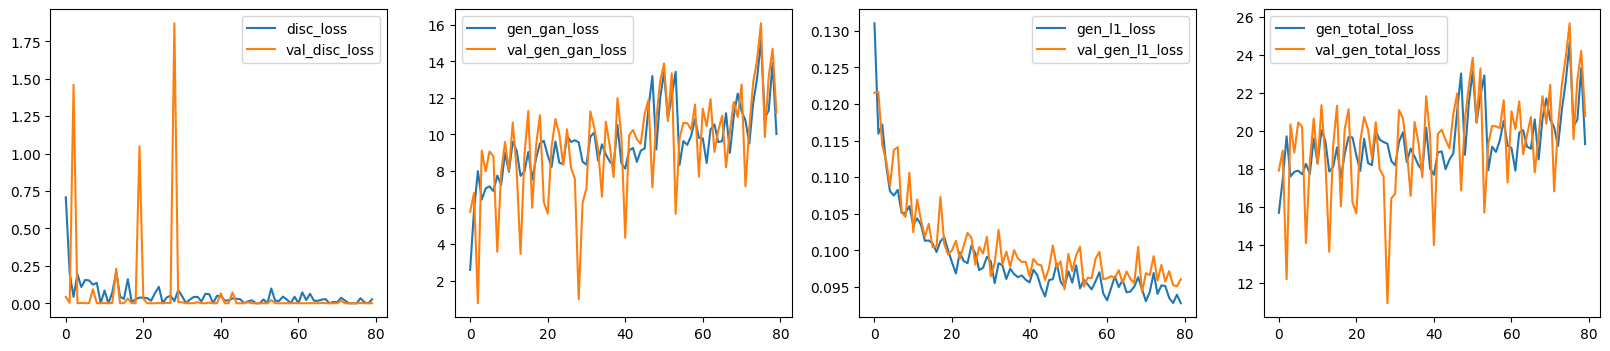

In [130]:
h = load_metrics(os.path.join(WORKING_DIR, 'history.json'))

fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(20, 4))

ax[0].plot(h['disc_loss'], label='disc_loss')
ax[0].plot(h['val_disc_loss'], label='val_disc_loss')
ax[0].legend()

ax[1].plot(h['gen_gan_loss'], label='gen_gan_loss')
ax[1].plot(h['val_gen_gan_loss'], label='val_gen_gan_loss')
ax[1].legend()

ax[2].plot(h['gen_l1_loss'], label='gen_l1_loss')
ax[2].plot(h['val_gen_l1_loss'], label='val_gen_l1_loss')
ax[2].legend()

ax[3].plot(h['gen_total_loss'], label='gen_total_loss')
ax[3].plot(h['val_gen_total_loss'], label='val_gen_total_loss')
ax[3].legend()

plt.show()

## Historical images

In [82]:
def make_square(img):
    w, h = img.size
 
    # Side length of the square (smallest dimension)
    side = min(w, h)

    # Coordinates for centered square
    left   = (w - side) // 2
    top    = (h - side) // 2
    right  = left + side
    bottom = top + side

    square = img.crop((left, top, right, bottom))
    return square.resize((256,256))

def trim_margins(img):
    w,h = img.size
    return img.crop([50, 50, w-50, h-50])

def download_image(url):
    response = requests.get(url)
    return Image.open(io.BytesIO(response.content))

def prepare_image(url):
    img = download_image(url)
    img = trim_margins(img)
    img = make_square(img)
    img = np.asarray(img) / 255.0
    img = to_m11(img)
    return img

In [83]:
images = [
    prepare_image('https://s3.us-east-1.amazonaws.com/NARAprodstorage/lz/stillpix/079-aah/079-AAH-03_14-1387M.TIF'),
    prepare_image('https://s3.us-east-1.amazonaws.com/NARAprodstorage/lz/stillpix/079-aag/079-AAG-01_14-1374M.TIF'),
    prepare_image('https://s3.us-east-1.amazonaws.com/NARAprodstorage/lz/stillpix/106-wb/106-WB-307_22-3138M.TIF'),
    prepare_image('https://s3.us-east-1.amazonaws.com/NARAprodstorage/lz/stillpix/106-wb/106-WB-322_22-3153M.TIF')
]

image_annotations = [
    # https://catalog.archives.gov/id/519537
    'Shoshone Canyon and Falls, Idaho Terr., in back- ground. By O\'Sullivan, 1868',

    # https://catalog.archives.gov/id/519904
    '"The Tetons - Snake River," Grand Teton National Park, Wyoming, 1933-1942',

    # https://catalog.archives.gov/id/524258
    'OAK GROVE WHITE MOUNTAINS, SIERRA BLANCA, ARIZONA, 1873',

    # https://catalog.archives.gov/id/524273
    'SOUTH SIDE OF INSCRIPTION ROCK, NEW MEXICO, 1873'
]


In [147]:
generator.load_weights(os.path.join(WORKING_DIR, 'model-epoch-070', 'generator.weights.h5'))
input_tensor = tf.stack(images)
output_tensor = generator.predict(input_tensor)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step


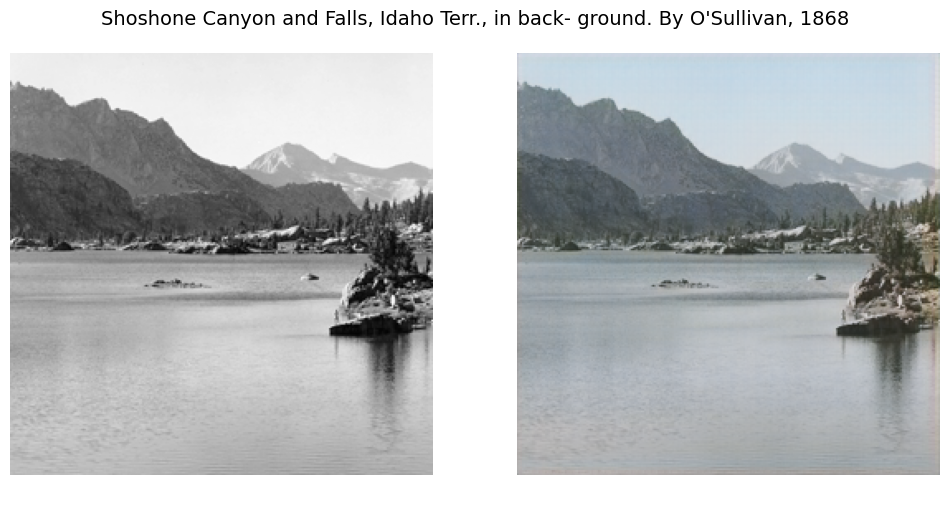

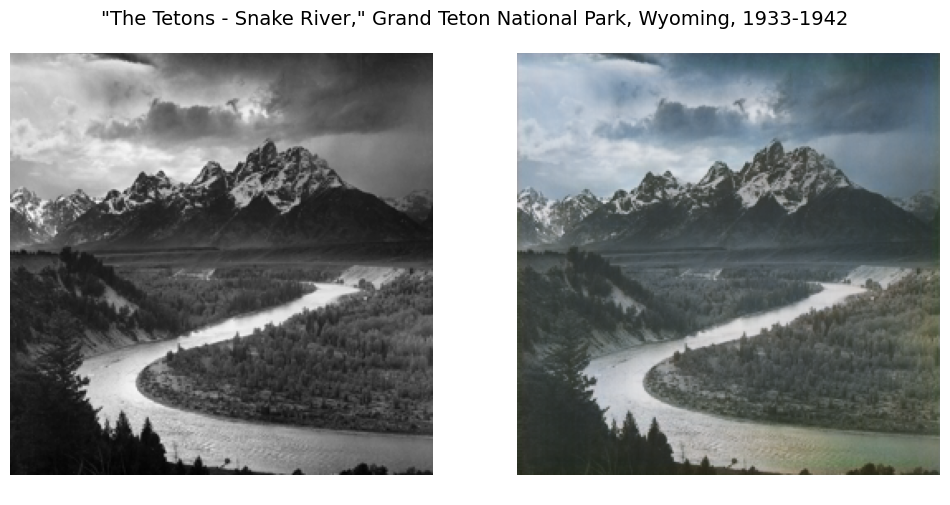

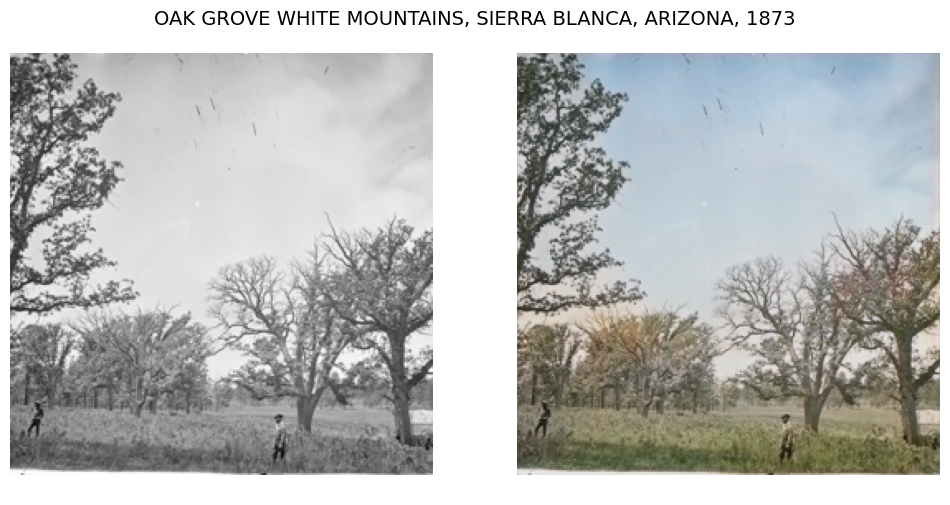

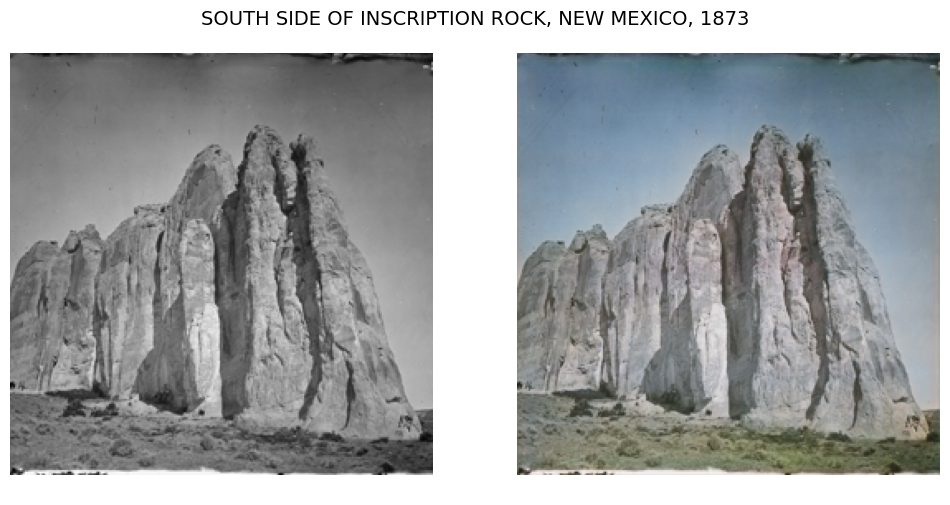

In [148]:
for x, yhat, annotation in zip(input_tensor, output_tensor, image_annotations):
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(to_01(x), cmap='gray')
    axes[1].imshow(to_01(yhat))
    
    axes[0].axis("off")
    axes[1].axis("off")

    ax_title = fig.add_subplot(1, 1, 1, frame_on=False)
    ax_title.set_title(annotation, fontsize=14)
    ax_title.axis("off")   # hide the dummy axis

    plt.show()

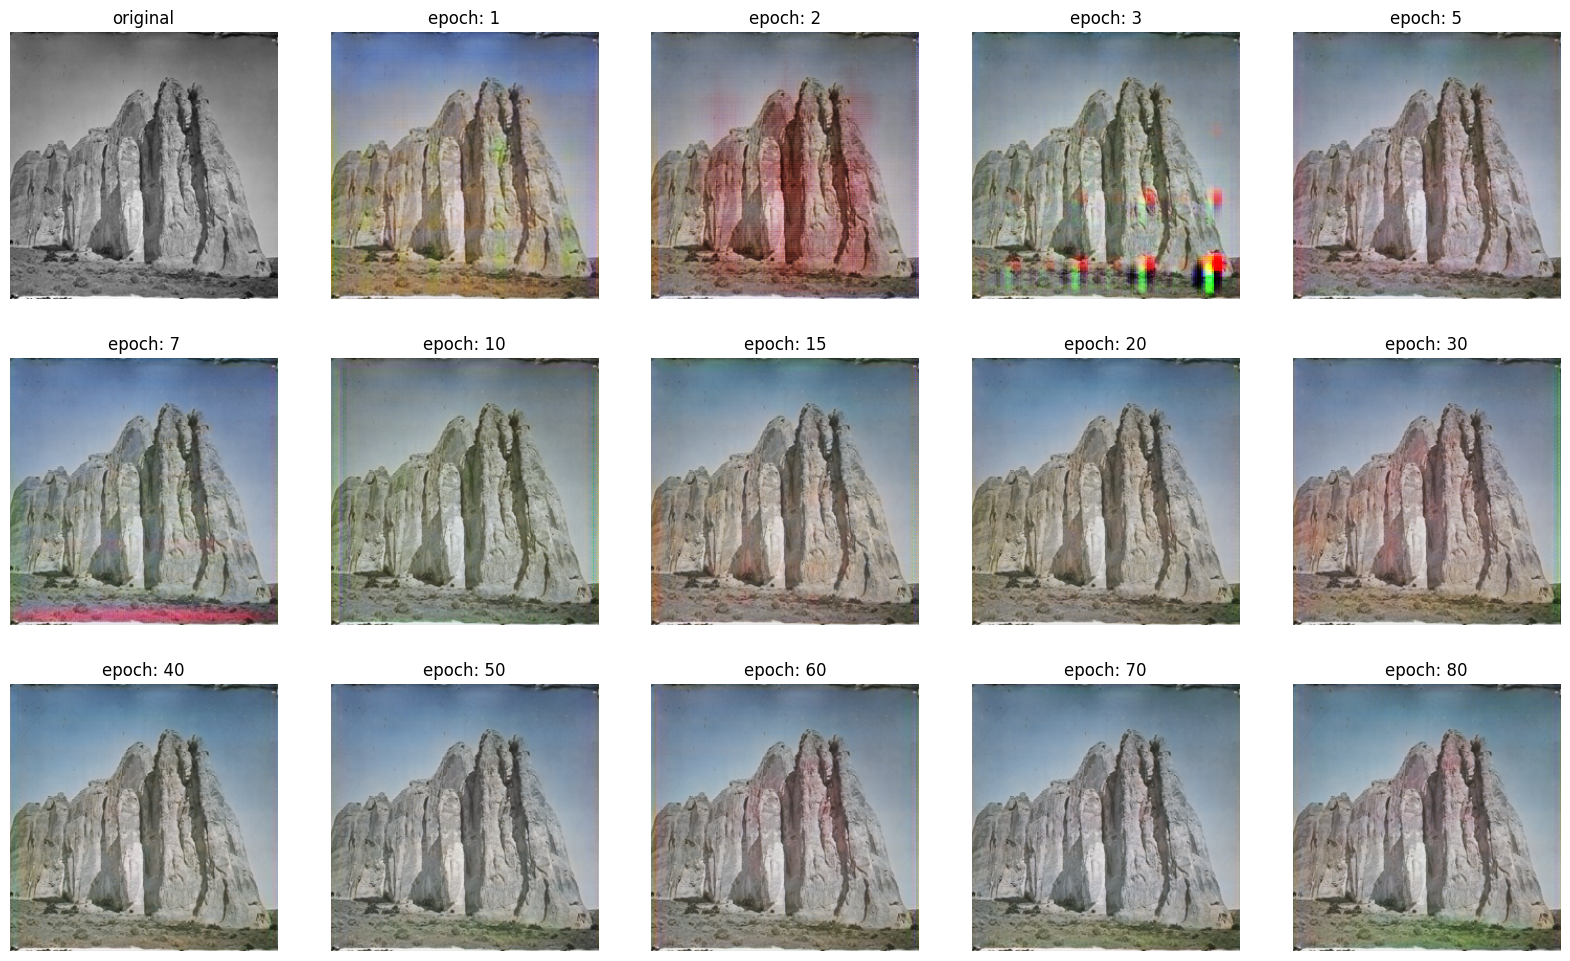

In [149]:
img = images[3]
input_tensor = tf.stack([img])

n, m = 3, 5
fig = plt.figure(figsize=(m*4, n*4))
ax = fig.add_subplot(n, m, 1)
ax.imshow(to_01(img), cmap='gray')
ax.set_title(f'original')
ax.axis("off")

for i, epoch in enumerate(save_epochs):
    generator.load_weights(os.path.join(WORKING_DIR, f'model-epoch-{epoch:03}', 'generator.weights.h5'))
    output_tensor = generator(input_tensor, training=False)
    yhat = output_tensor[0]

    ax = fig.add_subplot(n, m, i+2)
    ax.set_title(f'epoch: {epoch}')
    ax.imshow(to_01(yhat))
    ax.axis("off")


# Conclusion